In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split, Subset
from torchsummary import summary
import numpy as np
%load_ext autoreload
%autoreload 2
from utils import *

c:\Users\Leandro\anaconda3\envs\PyTorch_39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define data transformations with data augmentation for train
train_transform = transforms.Compose([
    transforms.Resize((256)),
    transforms.RandomRotation(20),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
# Load the given dataset
data_dir = './dogs'
dataset = ImageFolder(root=data_dir)
targets = dataset.targets

# 80% for training
# 20% for validation
# Stratification is used to ensure equal sampling of classes, necessary due to the limited data available.
train_idx, val_idx= train_test_split(np.arange(len(targets)), test_size=0.2, shuffle=True, stratify=targets)

train_dataset=Subset(dataset,train_idx)
val_dataset=Subset(dataset,val_idx)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Extra datasets that do not intervene in the training of the model
test_dataset = ImageFolder(root='./test',transform=val_transform)
other_dataset = ImageFolder(root='./Otros',transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
other_loader = DataLoader(other_dataset, batch_size=16, shuffle=False)


In [3]:
# Load the pre-trained ResNet model for transfer learning
model = models.resnet18(weights='DEFAULT')
for param in model.parameters(): param.requires_grad = False

# The final layer of the original model is replaced with a FC with the number of classes for this problem
num_classes = 4  # French Bulldog, German Shepherd, Golden Retriever, Poodle
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

#summary(model,(3,224,224))

cuda


100%|██████████| 4/4 [00:05<00:00,  1.29s/it]


Training epoch 1 | Loss 1.395600 | Accuracy 29.69% | Time 5.16 seconds
Validation epoch 1 | Loss 0.962626 | Accuracy 68.75% | Time 0.86 seconds


100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Training epoch 2 | Loss 1.068301 | Accuracy 60.94% | Time 3.69 seconds
Validation epoch 2 | Loss 0.742699 | Accuracy 87.50% | Time 0.87 seconds


100%|██████████| 4/4 [00:03<00:00,  1.20it/s]


...

Training epoch 11 | Loss 0.205812 | Accuracy 100.00% | Time 3.35 seconds
Validation epoch 11 | Loss 0.200524 | Accuracy 100.00% | Time 0.90 seconds
Retry:4


100%|██████████| 4/4 [00:03<00:00,  1.17it/s]


Training epoch 12 | Loss 0.194194 | Accuracy 98.44% | Time 3.41 seconds
Validation epoch 12 | Loss 0.183477 | Accuracy 100.00% | Time 0.88 seconds
Retry:5


100%|██████████| 4/4 [00:03<00:00,  1.20it/s]


Training epoch 13 | Loss 0.183183 | Accuracy 100.00% | Time 3.34 seconds
Validation epoch 13 | Loss 0.168495 | Accuracy 100.00% | Time 0.83 seconds
Retry:6
Early stopping
Best Epoch: 7
Validation - Best Model | Loss 0.298238 | Accuracy 100.00%
{'french_bulldog': 0, 'german_shepherd': 1, 'golden_retriever': 2, 'poodle': 3}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



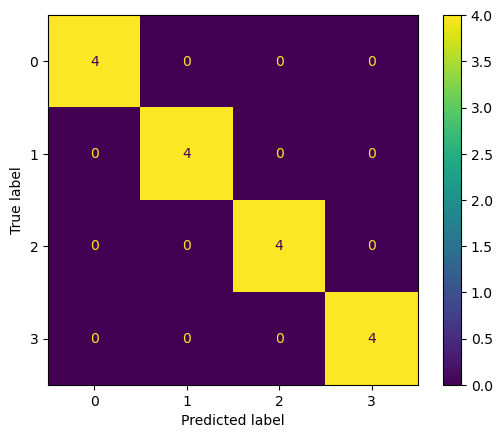

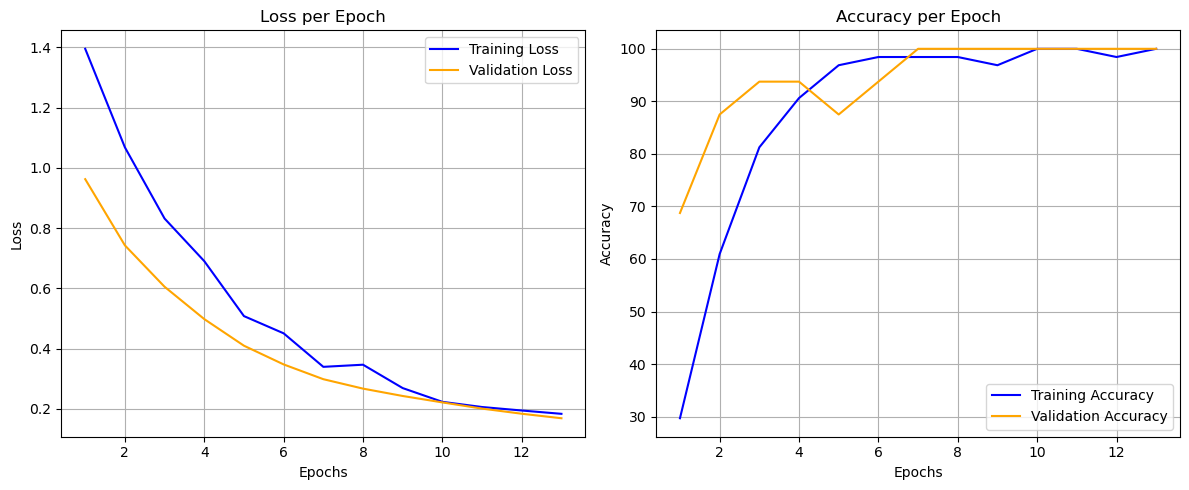

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# The model is trained with the original dataset without having any additional feedback
train_model(model, train_loader, val_loader, criterion, optimizer,device)

* Early stopping was used as a way to avoid overfitting, given that it is a very small set of images, the model could easily overfit
* By using transfer learning and being a small dataset, a high level of accuracy is quickly achieved
* There are only 16 samples for validation, so making an error significantly affects the metrics

In [5]:
# Load the pre-trained ResNet model for transfer learning
model = models.resnet18(weights='DEFAULT')
for param in model.parameters(): param.requires_grad = False

# The final layer of the original model is replaced with a FC with the number of classes for this problem
num_classes = 4  # French Bulldog, German Shepherd, Golden Retriever, Poodle
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

#summary(model,(3,224,224))

cuda


100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Training epoch 1 | Loss 1.388504 | Accuracy 35.94% | Time 3.78 seconds
Validation epoch 1 | Loss 1.123176 | Accuracy 43.75% | Time 0.96 seconds
Test epoch 1 | Loss 0.955684 | Accuracy 55.00% | Time 0.93 seconds


100%|██████████| 4/4 [00:03<00:00,  1.14it/s]


Training epoch 2 | Loss 1.049087 | Accuracy 65.62% | Time 3.52 seconds
Validation epoch 2 | Loss 0.889974 | Accuracy 62.50% | Time 0.92 seconds
Test epoch 2 | Loss 0.719968 | Accuracy 85.00% | Time 1.02 seconds


100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


...

Training epoch 13 | Loss 0.152413 | Accuracy 100.00% | Time 3.31 seconds
Validation epoch 13 | Loss 0.144462 | Accuracy 100.00% | Time 0.83 seconds
Test epoch 13 | Loss 0.165249 | Accuracy 100.00% | Time 0.87 seconds
Retry:4


100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Training epoch 14 | Loss 0.169324 | Accuracy 96.88% | Time 3.73 seconds
Validation epoch 14 | Loss 0.137289 | Accuracy 100.00% | Time 0.86 seconds
Test epoch 14 | Loss 0.157275 | Accuracy 100.00% | Time 0.99 seconds
Retry:5


100%|██████████| 4/4 [00:03<00:00,  1.16it/s]


Training epoch 15 | Loss 0.141556 | Accuracy 100.00% | Time 3.44 seconds
Validation epoch 15 | Loss 0.128024 | Accuracy 100.00% | Time 0.82 seconds
Test epoch 15 | Loss 0.149925 | Accuracy 100.00% | Time 0.84 seconds
Retry:6
Early stopping
Best Epoch: 9
Validation - Best Model | Loss 0.215928 | Accuracy 100.00%
Test - Best Model | Loss 0.217056 | Accuracy 100.00%
{'french_bulldog': 0, 'german_shepherd': 1, 'golden_retriever': 2, 'poodle': 3}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



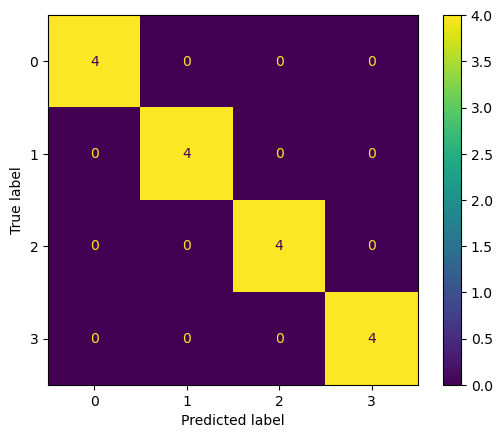

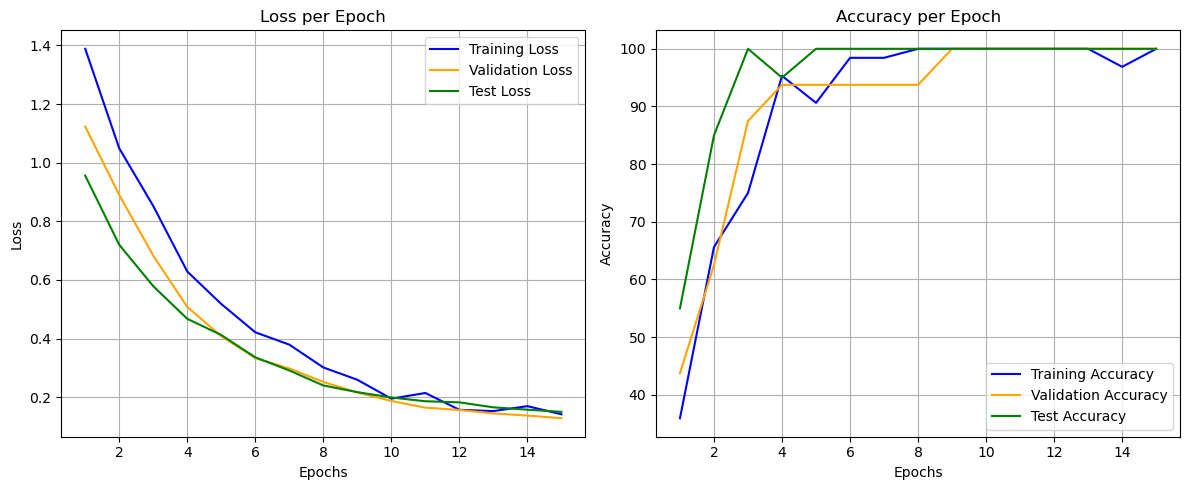

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# The model is trained with the original dataset and an extra test dataset is used just to have more feedback
train_model_wtest(model, train_loader, val_loader, test_loader, criterion, optimizer,device)

For the extra test dataset, the same metric is obtained, which is a good validation since it was not used in any way during the training phase

In [7]:
# Load the pre-trained ResNet model for transfer learning
model = models.resnet18(weights='DEFAULT')
for param in model.parameters(): param.requires_grad = False

# The final layer of the original model is replaced with a FC with the number of classes for this problem
num_classes = 4  # French Bulldog, German Shepherd, Golden Retriever, Poodle
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

#summary(model,(3,224,224))

cuda


100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Training epoch 1 | Loss 1.406406 | Accuracy 32.81% | Time 3.92 seconds
Validation epoch 1 | Loss 1.090840 | Accuracy 75.00% | Time 0.85 seconds
Test epoch 1 | Loss 1.122187 | Accuracy 60.00% | Time 0.98 seconds
Other epoch 1 | Accuracy 100.00% | Time 0.28 seconds


100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Training epoch 2 | Loss 1.086667 | Accuracy 64.06% | Time 3.68 seconds
Validation epoch 2 | Loss 0.859579 | Accuracy 100.00% | Time 0.86 seconds
Test epoch 2 | Loss 0.836073 | Accuracy 80.00% | Time 0.87 seconds
Other epoch 2 | Accuracy 83.33% | Time 0.24 seconds


100%|██████████| 4/4 [00:03<00:00,  1.14it/s]


...

Training epoch 6 | Loss 0.528472 | Accuracy 96.88% | Time 3.39 seconds
Validation epoch 6 | Loss 0.369827 | Accuracy 100.00% | Time 0.82 seconds
Test epoch 6 | Loss 0.430706 | Accuracy 95.00% | Time 0.87 seconds
Other epoch 6 | Accuracy 83.33% | Time 0.27 seconds
Retry:4


100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Training epoch 7 | Loss 0.363007 | Accuracy 100.00% | Time 3.66 seconds
Validation epoch 7 | Loss 0.316275 | Accuracy 100.00% | Time 0.82 seconds
Test epoch 7 | Loss 0.367192 | Accuracy 100.00% | Time 0.88 seconds
Other epoch 7 | Accuracy 66.67% | Time 0.23 seconds
Retry:5


100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Training epoch 8 | Loss 0.380423 | Accuracy 96.88% | Time 3.67 seconds
Validation epoch 8 | Loss 0.266296 | Accuracy 100.00% | Time 0.94 seconds
Test epoch 8 | Loss 0.297383 | Accuracy 100.00% | Time 0.96 seconds
Other epoch 8 | Accuracy 50.00% | Time 0.24 seconds
Retry:6
Early stopping
Best Epoch: 2
Validation - Best Model | Loss 0.859579 | Accuracy 100.00%
Test - Best Model | Loss 0.836073 | Accuracy 80.00%
Other - Best Model | Accuracy 83.33%
{'french_bulldog': 0, 'german_shepherd': 1, 'golden_retriever': 2, 'poodle': 3}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



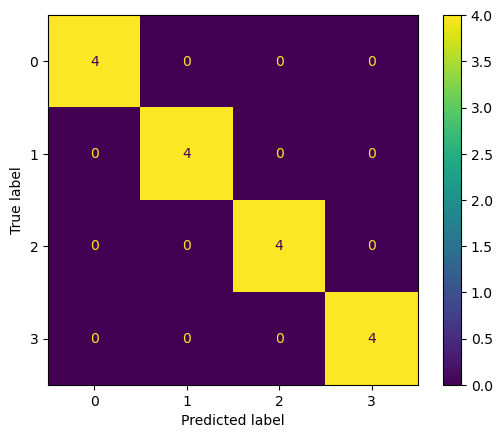

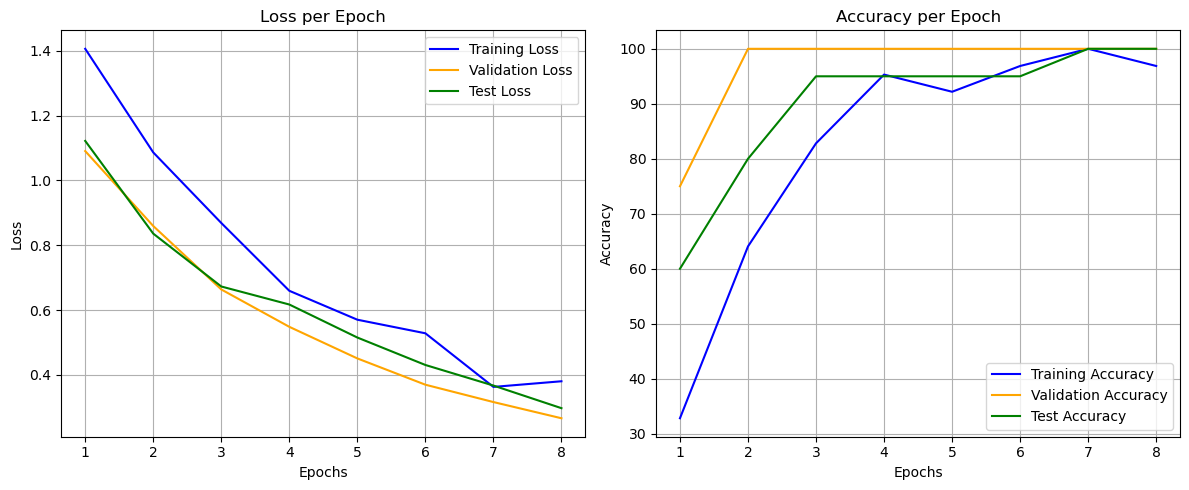

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# The model is trained with the original dataset and an extra test dataset is used just to have more feedback
# Additionally, a dataset is used with images of other races and elements, which simulate being another class.
# If none of the output neurons gives a probability greater than 0.5, it is the "other" class.
train_model_wtest_wother(model, train_loader, val_loader, test_loader, other_loader, criterion, optimizer, device)

For the 6 images from different categories, most of them were not classified as one of the original categories, so it also achieves a very good metric for that case.

In [9]:
# Load the pre-trained ResNet model for transfer learning
model = models.resnet18(weights='DEFAULT')
for param in model.parameters(): param.requires_grad = False

# The final layer of the original model is replaced with a FC with the number of classes for this problem
num_classes = 4  # French Bulldog, German Shepherd, Golden Retriever, Poodle
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

#summary(model,(3,224,224))

cuda


100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


Training epoch 1 | Loss 1.448333 | Accuracy 34.38% | Time 3.83 seconds
Validation epoch 1 | Loss 1.196840 | Accuracy 43.75% | Time 0.95 seconds
Test epoch 1 | Loss 1.198492 | Accuracy 40.00% | Time 1.10 seconds
Other epoch 1 | Accuracy 83.33% | Time 0.25 seconds


100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


Training epoch 2 | Loss 1.160652 | Accuracy 54.69% | Time 3.62 seconds
Validation epoch 2 | Loss 0.921499 | Accuracy 68.75% | Time 0.88 seconds
Test epoch 2 | Loss 0.932076 | Accuracy 70.00% | Time 0.94 seconds
Other epoch 2 | Accuracy 66.67% | Time 0.27 seconds


100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


...

Training epoch 11 | Loss 0.188061 | Accuracy 100.00% | Time 3.66 seconds
Validation epoch 11 | Loss 0.195912 | Accuracy 100.00% | Time 0.93 seconds
Test epoch 11 | Loss 0.274376 | Accuracy 100.00% | Time 1.02 seconds
Other epoch 11 | Accuracy 66.67% | Time 0.28 seconds
Retry:4


100%|██████████| 4/4 [00:03<00:00,  1.10it/s]


Training epoch 12 | Loss 0.230943 | Accuracy 98.44% | Time 3.64 seconds
Validation epoch 12 | Loss 0.184900 | Accuracy 100.00% | Time 0.87 seconds
Test epoch 12 | Loss 0.254857 | Accuracy 100.00% | Time 0.88 seconds
Other epoch 12 | Accuracy 66.67% | Time 0.26 seconds
Retry:5


100%|██████████| 4/4 [00:03<00:00,  1.20it/s]


Training epoch 13 | Loss 0.200127 | Accuracy 98.44% | Time 3.34 seconds
Validation epoch 13 | Loss 0.170187 | Accuracy 100.00% | Time 0.83 seconds
Test epoch 13 | Loss 0.233033 | Accuracy 100.00% | Time 0.87 seconds
Other epoch 13 | Accuracy 66.67% | Time 0.24 seconds
Retry:6
Early stopping
Best Epoch: 7
Validation - Best Model | Loss 0.313102 | Accuracy 100.00%
Test - Best Model | Loss 0.395880 | Accuracy 100.00%
Other - Best Model | Accuracy 66.67%
{'french_bulldog': 0, 'german_shepherd': 1, 'golden_retriever': 2, 'poodle': 3}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



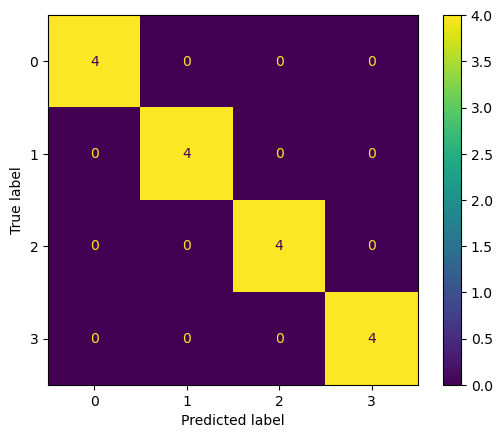

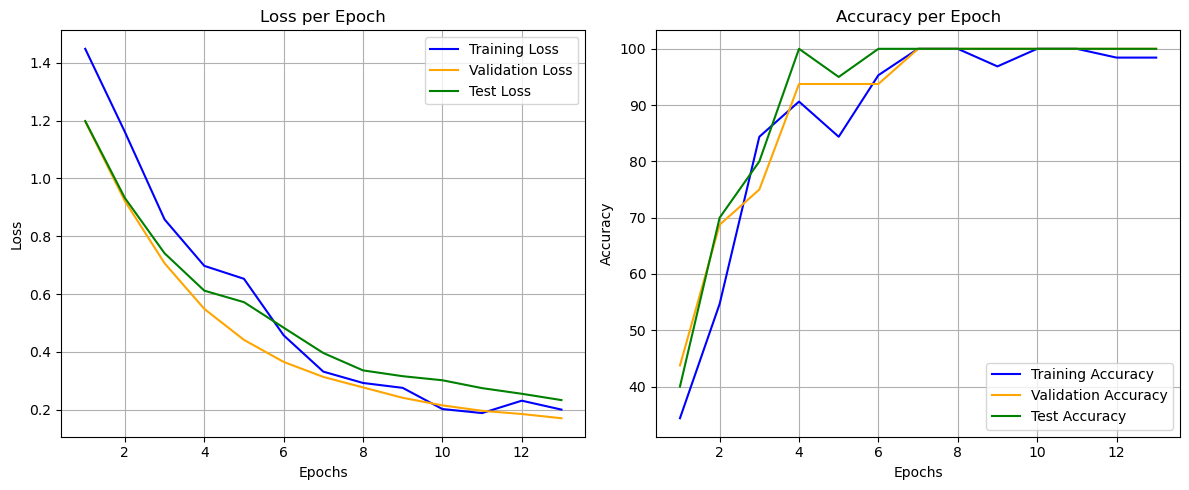

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
train_model_wtest_wother(model, train_loader, val_loader, test_loader, other_loader, criterion, optimizer, device)

Another pre-trained network is used as a basis for transfer learning.  
EfficientNet is used, which was also originally trained with the ImageNet dataset, but gives better results than ResNet with lower computational cost

In [11]:

model = models.efficientnet_b0(weights='DEFAULT')
for param in model.parameters(): param.requires_grad = False

# The final layer of the original model is replaced with a FC with the number of classes for this problem
num_classes = 4  # French Bulldog, German Shepherd, Golden Retriever, Poodle
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

#print(model)
#summary(model,(3,224,224))

cuda


100%|██████████| 4/4 [00:03<00:00,  1.13it/s]


Training epoch 1 | Loss 1.392085 | Accuracy 26.56% | Time 3.55 seconds
Validation epoch 1 | Loss 1.138900 | Accuracy 81.25% | Time 0.88 seconds
Test epoch 1 | Loss 1.173160 | Accuracy 70.00% | Time 0.90 seconds
Other epoch 1 | Accuracy 100.00% | Time 0.25 seconds


100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Training epoch 2 | Loss 1.159149 | Accuracy 67.19% | Time 3.66 seconds
Validation epoch 2 | Loss 0.963266 | Accuracy 93.75% | Time 0.85 seconds
Test epoch 2 | Loss 1.044670 | Accuracy 90.00% | Time 0.89 seconds
Other epoch 2 | Accuracy 100.00% | Time 0.24 seconds


100%|██████████| 4/4 [00:03<00:00,  1.14it/s]


...

Training epoch 8 | Loss 0.437588 | Accuracy 93.75% | Time 3.56 seconds
Validation epoch 8 | Loss 0.463041 | Accuracy 100.00% | Time 0.88 seconds
Test epoch 8 | Loss 0.674264 | Accuracy 90.00% | Time 0.89 seconds
Other epoch 8 | Accuracy 83.33% | Time 0.24 seconds
Retry:4


100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


Training epoch 9 | Loss 0.366439 | Accuracy 96.88% | Time 3.60 seconds
Validation epoch 9 | Loss 0.428303 | Accuracy 100.00% | Time 0.82 seconds
Test epoch 9 | Loss 0.628745 | Accuracy 95.00% | Time 0.88 seconds
Other epoch 9 | Accuracy 83.33% | Time 0.24 seconds
Retry:5


100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Training epoch 10 | Loss 0.304553 | Accuracy 100.00% | Time 3.76 seconds
Validation epoch 10 | Loss 0.396476 | Accuracy 100.00% | Time 0.80 seconds
Test epoch 10 | Loss 0.598082 | Accuracy 95.00% | Time 0.86 seconds
Other epoch 10 | Accuracy 83.33% | Time 0.24 seconds
Retry:6
Early stopping
Best Epoch: 4
Validation - Best Model | Loss 0.688947 | Accuracy 100.00%
Test - Best Model | Loss 0.851216 | Accuracy 95.00%
Other - Best Model | Accuracy 100.00%
{'french_bulldog': 0, 'german_shepherd': 1, 'golden_retriever': 2, 'poodle': 3}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



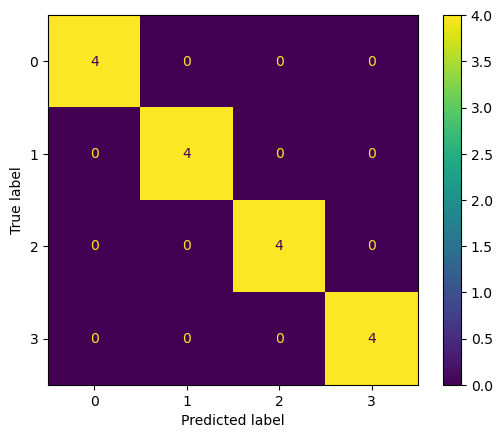

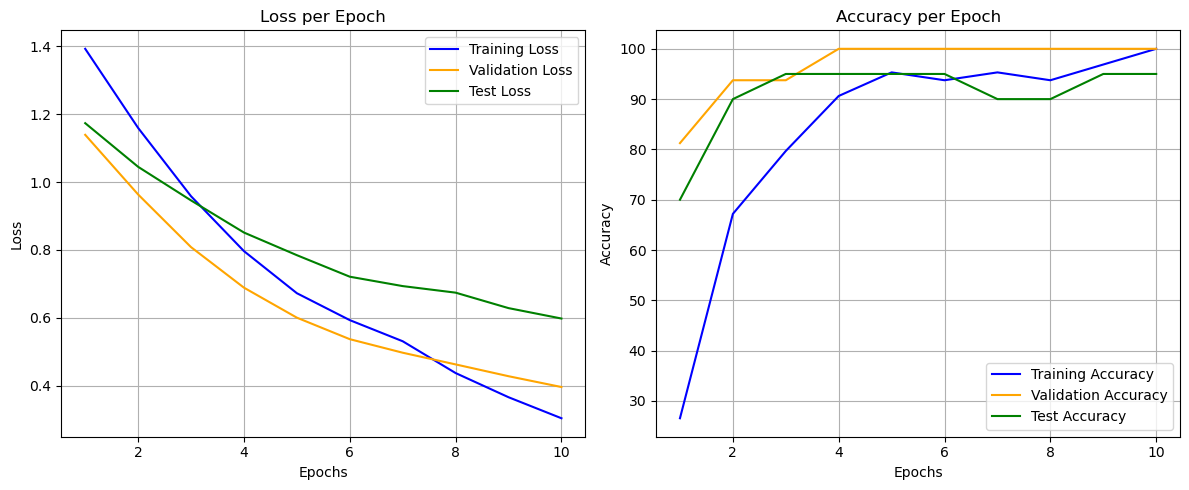

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_model_wtest_wother(model, train_loader, val_loader, test_loader, other_loader, criterion, optimizer, device)